# Product Review Sentiment Analysis
### End-to-End NLP Project
**Dataset:** Flipkart Product Reviews  
**Goal:** Classify customer reviews into Positive, Neutral, and Negative sentiments using multiple approaches including VADER, TextBlob, and Rating-based labeling.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')


All libraries imported successfully.


In [2]:
# NLP Libraries
import re
import string
from collections import Counter

from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline



NLP and ML libraries imported successfully.


## 2. Load Dataset

In [3]:
# Loading the Flipkart Review dataset here
df_raw = pd.read_csv('dataset.csv', encoding='latin-1', low_memory=False)
print(f"Dataset loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Dataset loaded: 363,261 rows x 5 columns


,Product_name,Price,Rate,Review,Summary
0,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Simply awesome,it's really worth every single penny. it works...
1,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",4,Worth the money . Desert Cooler live up to the...,I bought Crompton Ozone 75 Desert Air Cooler i...
2,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Worth every penny,GREAT packaging by seller. As this was the mos...
3,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Fabulous!,Delivery was delayed by two days except this e...
4,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",4,Nice product,A Good cooler by Crompton. The height of the c...


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363261 entries, 0 to 363260
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Product_name  363246 non-null  object
 1   Price         363245 non-null  object
 2   Rate          363245 non-null  object
 3   Review        363239 non-null  object
 4   Summary       361239 non-null  object
dtypes: object(5)
memory usage: 13.9+ MB


In [5]:
print("Column Data Types:")
print(df_raw.dtypes)
print(f"\nMemory Usage: {df_raw.memory_usage(deep=True).sum() / 1e6:.2f} MB")

Column Data Types:
Product_name    object
Price           object
Rate            object
Review          object
Summary         object
dtype: object

Memory Usage: 173.80 MB


In [6]:
print("First 5 rows:")
df_raw.head()

First 5 rows:


,Product_name,Price,Rate,Review,Summary
0,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Simply awesome,it's really worth every single penny. it works...
1,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",4,Worth the money . Desert Cooler live up to the...,I bought Crompton Ozone 75 Desert Air Cooler i...
2,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Worth every penny,GREAT packaging by seller. As this was the mos...
3,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",5,Fabulous!,Delivery was delayed by two days except this e...
4,"Crompton 75 L Desert Air Cooler??(White, Tea...","??10,499",4,Nice product,A Good cooler by Crompton. The height of the c...


In [7]:
print("Last 5 rows:")
df_raw.tail()

Last 5 rows:


,Product_name,Price,Rate,Review,Summary
363256,"NIVEA Soft Light Moisturizer for Face, Hand & ...",??142,5,Terrific,Thanks
363257,"NIVEA Soft Light Moisturizer for Face, Hand & ...",??142,5,Terrific,Good
363258,"NIVEA Soft Light Moisturizer for Face, Hand & ...",??142,5,Just wow!,Super
363259,"NIVEA Soft Light Moisturizer for Face, Hand & ...",??142,4,Worth the money,Good
363260,,NaN,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

In [8]:
df_raw.describe(include='all')

,Product_name,Price,Rate,Review,Summary
count,363246,363245,363245,363239,361239
unique,1175,709,9,3841,165850
top,Bumtum Baby Pull-Up Diaper Pants Combo Pack - ...,"??4,499",5,Wonderful,Good
freq,9937,12633,203832,18567,25001


In [9]:
# Missing value analysis
missing = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().sum() / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print("Missing Values per Column:")
print(missing_df)

Missing Values per Column:
              Missing Count  Missing %
Product_name             15       0.00
Price                    16       0.00
Rate                     16       0.00
Review                   22       0.01
Summary                2022       0.56


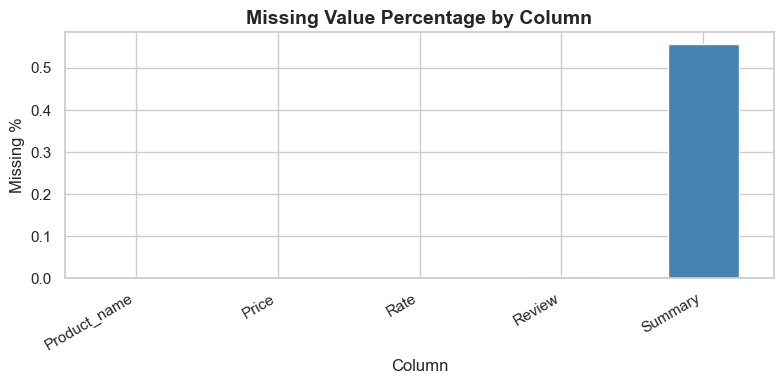

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Missing Value Percentage by Column', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('Column')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print(f"Duplicate rows: {df_raw.duplicated().sum():,}")
print(f"Unique Products: {df_raw['Product_name'].nunique():,}")

Duplicate rows: 53,786
Unique Products: 1,175


## 4. Data Cleaning

In [12]:
# Remove rows where Rate column contains non-numeric / header repetition artifacts
df = df_raw.copy()
df = df[pd.to_numeric(df['Rate'], errors='coerce').notna()].reset_index(drop=True)
df['Rate'] = df['Rate'].astype(int)
print(f"After removing bad Rate rows: {len(df):,}")

After removing bad Rate rows: 363,239


In [52]:
# Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Removed {before - len(df):,} duplicate rows. Remaining: {len(df):,}")

Removed 213 duplicate rows. Remaining: 307,759


In [14]:
# Drop rows with null review or summary
df.dropna(subset=['Review', 'Summary'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"After dropping null Review/Summary rows: {len(df):,}")

After dropping null Review/Summary rows: 307,972


In [15]:
# Clean Price column
df['Price'] = df['Price'].astype(str).str.replace(',','').str.extract(r'(\d+\.?\d*)')[0]
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
print(f"Price column cleaned. Sample values: {df['Price'].dropna().head(5).tolist()}")
print(f"Price nulls after cleaning: {df['Price'].isnull().sum():,}")

Price column cleaned. Sample values: [10499, 10499, 10499, 10499, 10499]
Price nulls after cleaning: 0


In [16]:
# Filter valid rating range 1-5
df = df[df['Rate'].between(1, 5)].reset_index(drop=True)
print(f"After rating filter: {len(df):,} rows")
print("Rating distribution:")
print(df['Rate'].value_counts().sort_index())

After rating filter: 307,972 rows
Rating distribution:
Rate
1     37692
2     12230
3     27980
4     60380
5    169690
Name: count, dtype: int64


In [17]:
# Sample for faster processing in notebook (use full for production)
# Use 50K sample for EDA and model training speed
SAMPLE_SIZE = 50000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"Working sample size: {len(df_sample):,}")

Working sample size: 50,000


## 5. Rating Distribution Analysis

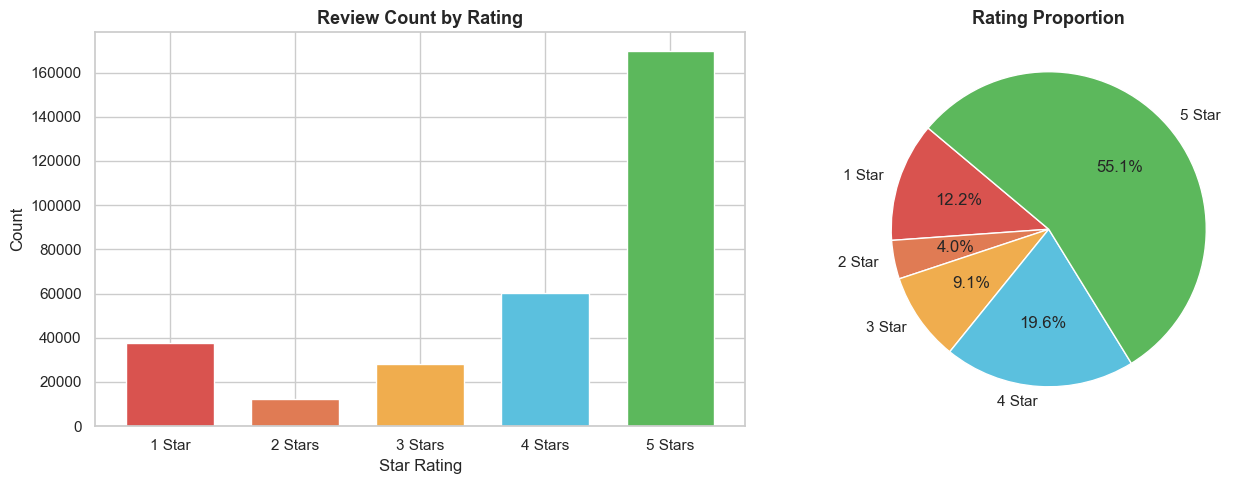

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
df['Rate'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color=['#d9534f','#e07b54','#f0ad4e','#5bc0de','#5cb85c'], edgecolor='white', width=0.7)
axes[0].set_title('Review Count by Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['1 Star','2 Stars','3 Stars','4 Stars','5 Stars'], rotation=0)

# Pie chart
pct = df['Rate'].value_counts().sort_index()
axes[1].pie(pct, labels=[f'{i} Star' for i in pct.index],
            autopct='%1.1f%%', startangle=140,
            colors=['#d9534f','#e07b54','#f0ad4e','#5bc0de','#5cb85c'])
axes[1].set_title('Rating Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Rating stats
print("Rating Statistics:")
print(df['Rate'].describe())
print(f"\nAverage Rating: {df['Rate'].mean():.2f}")
print(f"Median Rating: {df['Rate'].median():.0f}")
print(f"Mode Rating: {df['Rate'].mode()[0]}")

Rating Statistics:
count    307972.000000
mean          4.013553
std           1.379131
min           1.000000
25%           3.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: Rate, dtype: float64

Average Rating: 4.01
Median Rating: 5
Mode Rating: 5


## 6. Price Analysis

In [20]:
df_price = df.dropna(subset=['Price'])
print(f"Price stats:")
print(df_price['Price'].describe())

Price stats:
count    307972.000000
mean       4774.923707
std        8314.967519
min          59.000000
25%         499.000000
50%        1999.000000
75%        5437.000000
max       86990.000000
Name: Price, dtype: float64


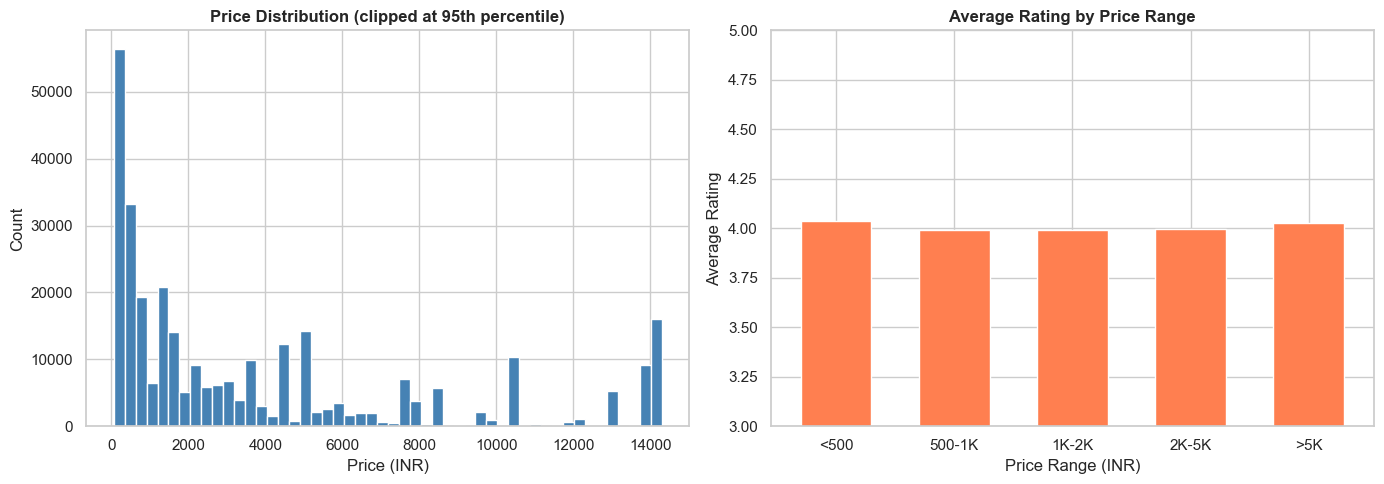

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution (log scale)
axes[0].hist(df_price['Price'].clip(upper=df_price['Price'].quantile(0.95)),
             bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (clipped at 95th percentile)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price (INR)')
axes[0].set_ylabel('Count')

# Avg rating by price bucket
df_price['price_bucket'] = pd.cut(df_price['Price'],
    bins=[0, 500, 1000, 2000, 5000, 100000],
    labels=['<500', '500-1K', '1K-2K', '2K-5K', '>5K'])
avg_rating = df_price.groupby('price_bucket', observed=True)['Rate'].mean()
avg_rating.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white', width=0.6)
axes[1].set_title('Average Rating by Price Range', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price Range (INR)')
axes[1].set_ylabel('Average Rating')
axes[1].set_xticklabels(avg_rating.index, rotation=0)
axes[1].set_ylim(3, 5)

plt.tight_layout()
plt.savefig('price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Top Products Analysis

In [22]:
# Top 10 most reviewed products
top_products = df['Product_name'].value_counts().head(10).reset_index()
top_products.columns = ['Product', 'Review Count']
# Truncate long names

top_products['Product'] = top_products['Product'].str[:40]
print("Top 10 Most Reviewed Products:")
top_products

Top 10 Most Reviewed Products:


,Product,Review Count
0,cello Pack of 18 Opalware Cello Dazzle L,6947
1,Bumtum Baby Pull-Up Diaper Pants Combo P,6900
2,Google Home Mini with Google Assistant S,6836
3,Mi 5A 80 cm (32 inch) HD Ready LED Smart,6522
4,MILTON Thermosteel Flip Lid 500 ml Flask,5935
5,Lakm?? Eyeconic Kajal Twin Pack??(Deep,5071
6,Crompton 75 L Desert Air Cooler??(Whit,4481
7,Crompton 88 L Desert Air Cooler with Hon,4481
8,PHILIPS MMS8085B/94 Convertible 80 W Blu,4232
9,PHILIPS MMS2220B/94 120 W Bluetooth Home,4224


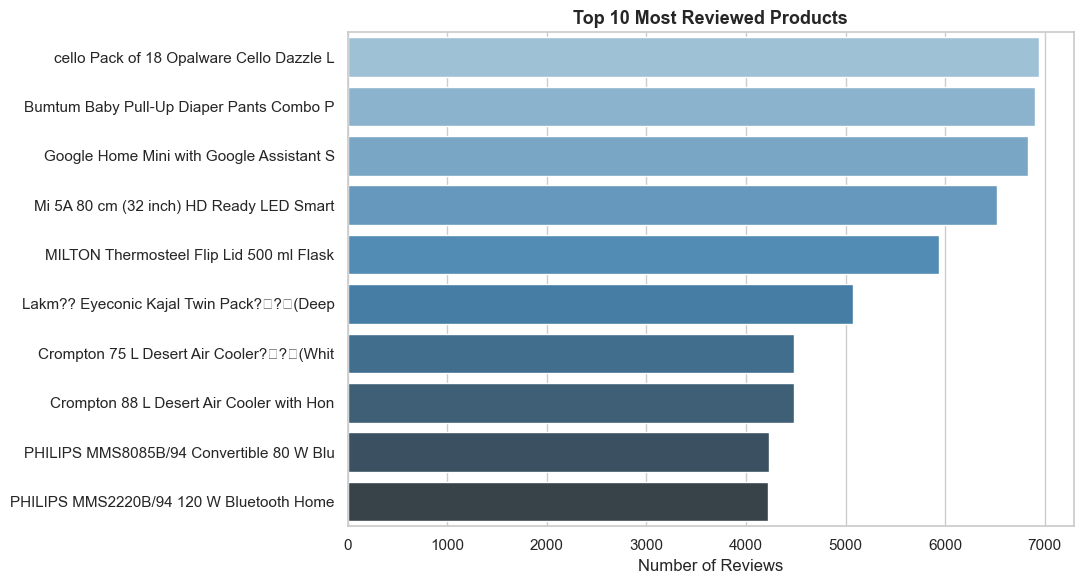

In [23]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top_products, y='Product', x='Review Count', ax=ax,
            palette='Blues_d', orient='h')

ax.set_title('Top 10 Most Reviewed Products', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('top_products.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
# Top rated products with at least 500 reviews
top_rated = (df.groupby('Product_name')
               .agg(avg_rating=('Rate','mean'), review_count=('Rate','count'))
               .query('review_count >= 500')
               .sort_values('avg_rating', ascending=False)
               .head(10)
               .reset_index())


top_rated['Product_name'] = top_rated['Product_name'].str[:40]
print("Top Rated Products (min 500 reviews):")
top_rated

Top Rated Products (min 500 reviews):


,Product_name,avg_rating,review_count
0,APPLE 2020 Macbook Air M1 - (8 GB/256 GB,4.781794,747
1,DOMS Pencil Smart Kit,4.713266,1681
2,HAIR & CARE Triple Blend Damage Repair N,4.648850,1478
3,Mivi Fort S16 Soundbar with 2 full range,4.600368,1086
4,Dettol Effective Protection Antiseptic L,4.557584,712
5,boAt Aavante Bar 120 W Bluetooth Soundba,4.551648,910
6,cello ColourUp Hobby Bag of Assorted Sta,4.534620,881
7,Mivi Fort S60 with 2 in-built subwoofers,4.531250,1760
8,Lakm?? Eyeconic Kajal Twin Pack??(Deep,4.515875,5071
9,SAMSUNG 253 L Frost Free Double Door 3 S,4.500663,1508


## 8. Sentiment Labeling

In [25]:
# Method 1: Rating-based sentiment labels
def rating_to_sentiment(r):
    if r >= 4:
        return 'Positive'
    elif r == 3:
        return 'Neutral'
    else:
        return 'Negative'


df_sample['sentiment_label'] = df_sample['Rate'].apply(rating_to_sentiment)
print("Rating-based Sentiment Distribution:")
print(df_sample['sentiment_label'].value_counts())

Rating-based Sentiment Distribution:
sentiment_label
Positive    37446
Negative     7992
Neutral      4562
Name: count, dtype: int64


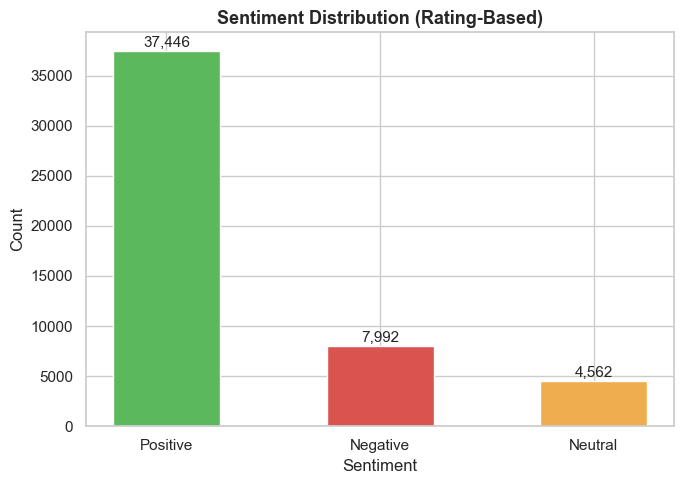

In [26]:
# Visualize sentiment distribution
fig, ax = plt.subplots(figsize=(7, 5))
colors = {'Positive': '#5cb85c', 'Neutral': '#f0ad4e', 'Negative': '#d9534f'}
sentiment_counts = df_sample['sentiment_label'].value_counts()

bars = ax.bar(sentiment_counts.index, sentiment_counts.values,
       color=[colors[s] for s in sentiment_counts.index], edgecolor='white', width=0.5)

for bar, val in zip(bars, sentiment_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=11)
    
ax.set_title('Sentiment Distribution (Rating-Based)', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Sentiment')
plt.tight_layout()
plt.savefig('sentiment_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Text Preprocessing

In [27]:
# Text cleaning function
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_sample['clean_review'] = df_sample['Review'].apply(clean_text)
df_sample['clean_summary'] = df_sample['Summary'].apply(clean_text)
df_sample['combined_text'] = df_sample['clean_summary'] + ' ' + df_sample['clean_review']
print("Sample cleaned text:")
print(df_sample['combined_text'].iloc[0][:300])

Sample cleaned text:
super fast delivery by flipkart and for this budget range sound quality is awesome prosdesign and looksdecent sound quality consas of now the bass control is not thereafter using i will update the cons pretty good


In [28]:
# Review length analysis
df_sample['review_length'] = df_sample['clean_review'].str.split().str.len()
df_sample['summary_length'] = df_sample['clean_summary'].str.split().str.len()

print("Review Length Stats:")
print(df_sample['review_length'].describe())

Review Length Stats:
count    50000.000000
mean         1.988700
std          0.957199
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         16.000000
Name: review_length, dtype: float64


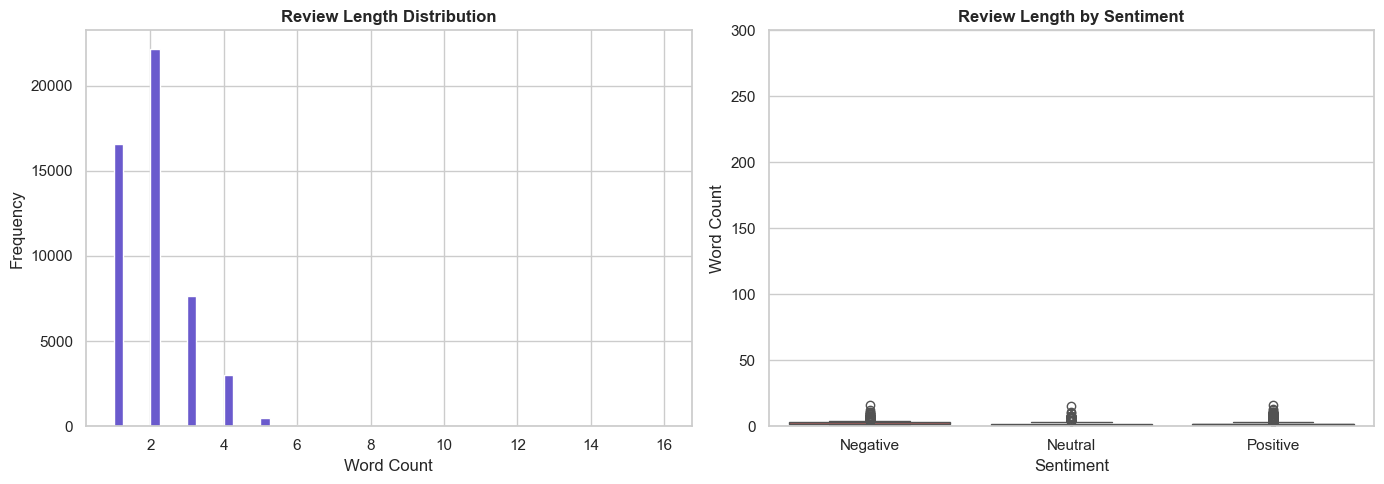

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_sample['review_length'].clip(upper=500), bins=60, color='slateblue', edgecolor='white')
axes[0].set_title('Review Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

# Review length by sentiment
sns.boxplot(data=df_sample, x='sentiment_label', y='review_length',
            palette=colors, ax=axes[1],
            order=['Negative','Neutral','Positive'])

axes[1].set_ylim(0, 300)
axes[1].set_title('Review Length by Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('review_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. VADER Sentiment Analysis

In [30]:
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive', compound
    elif compound <= -0.05:
        return 'Negative', compound
    else:
        return 'Neutral', compound

# Apply VADER on combined text
results = df_sample['combined_text'].apply(get_vader_sentiment)
df_sample['vader_sentiment'] = results.apply(lambda x: x[0])
df_sample['vader_compound'] = results.apply(lambda x: x[1])
print("VADER Sentiment Distribution:")
print(df_sample['vader_sentiment'].value_counts())

VADER Sentiment Distribution:
vader_sentiment
Positive    41550
Negative     7338
Neutral      1112
Name: count, dtype: int64


In [31]:
# Compare VADER vs Rating-based labels
print("Agreement between Rating-based and VADER sentiments:")
agreement = (df_sample['sentiment_label'] == df_sample['vader_sentiment']).mean()
print(f"Agreement Rate: {agreement:.2%}")

Agreement between Rating-based and VADER sentiments:
Agreement Rate: 86.68%


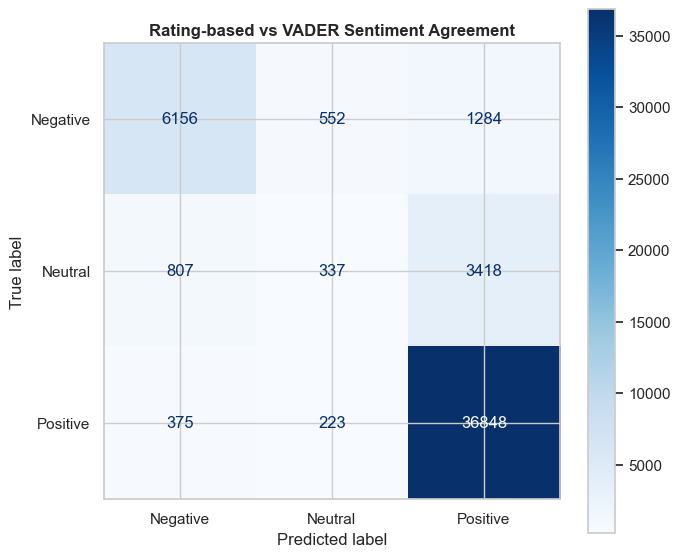

In [32]:
# Confusion matrix: rating label vs VADER
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(df_sample['sentiment_label'], df_sample['vader_sentiment'],
                      labels=['Negative','Neutral','Positive'])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative','Neutral','Positive'])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Rating-based vs VADER Sentiment Agreement', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('vader_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. TextBlob Sentiment Analysis

In [33]:
def get_textblob_sentiment(text):
    try:
        analysis = TextBlob(text)
        polarity = analysis.sentiment.polarity
        if polarity > 0.1:
            return 'Positive', polarity
        elif polarity < -0.1:
            return 'Negative', polarity
        else:
            return 'Neutral', polarity
    except:
        return 'Neutral', 0.0

tb_results = df_sample['combined_text'].apply(get_textblob_sentiment)
df_sample['textblob_sentiment'] = tb_results.apply(lambda x: x[0])
df_sample['textblob_polarity'] = tb_results.apply(lambda x: x[1])
print("TextBlob Sentiment Distribution:")
print(df_sample['textblob_sentiment'].value_counts())

TextBlob Sentiment Distribution:
textblob_sentiment
Positive    40934
Negative     6022
Neutral      3044
Name: count, dtype: int64


In [34]:
# Sentiment comparison table
comparison = pd.DataFrame({
    'Method': ['Rating-Based', 'VADER', 'TextBlob'],
    'Positive': [
        (df_sample['sentiment_label']=='Positive').sum(),
        (df_sample['vader_sentiment']=='Positive').sum(),
        (df_sample['textblob_sentiment']=='Positive').sum()
    ],
    'Neutral': [
        (df_sample['sentiment_label']=='Neutral').sum(),
        (df_sample['vader_sentiment']=='Neutral').sum(),
        (df_sample['textblob_sentiment']=='Neutral').sum()
    ],
    'Negative': [
        (df_sample['sentiment_label']=='Negative').sum(),
        (df_sample['vader_sentiment']=='Negative').sum(),
        (df_sample['textblob_sentiment']=='Negative').sum()
    ]
})
print("Comparison of Sentiment Methods:")
comparison

Comparison of Sentiment Methods:


,Method,Positive,Neutral,Negative
0,Rating-Based,37446,4562,7992
1,VADER,41550,1112,7338
2,TextBlob,40934,3044,6022


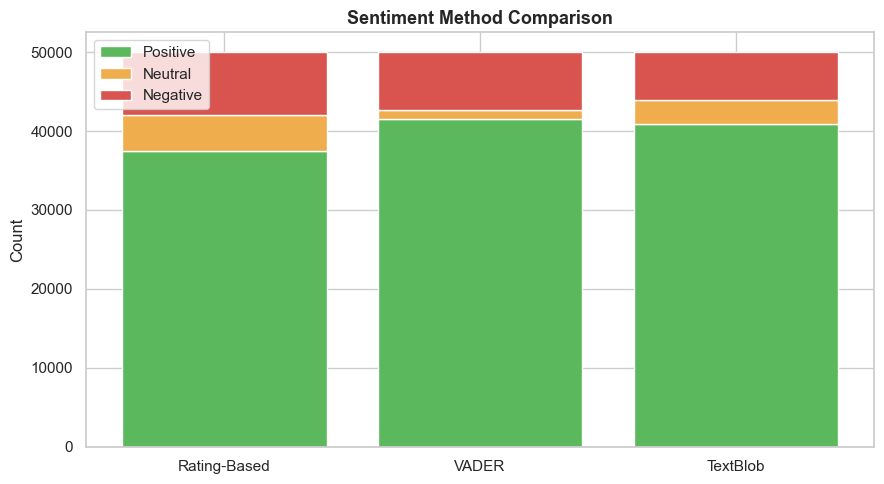

In [35]:
# Stacked bar comparison
fig, ax = plt.subplots(figsize=(9, 5))
x = comparison['Method']
ax.bar(x, comparison['Positive'], label='Positive', color='#5cb85c')
ax.bar(x, comparison['Neutral'], bottom=comparison['Positive'], label='Neutral', color='#f0ad4e')
ax.bar(x, comparison['Negative'],
       bottom=comparison['Positive']+comparison['Neutral'], label='Negative', color='#d9534f')
ax.set_title('Sentiment Method Comparison', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

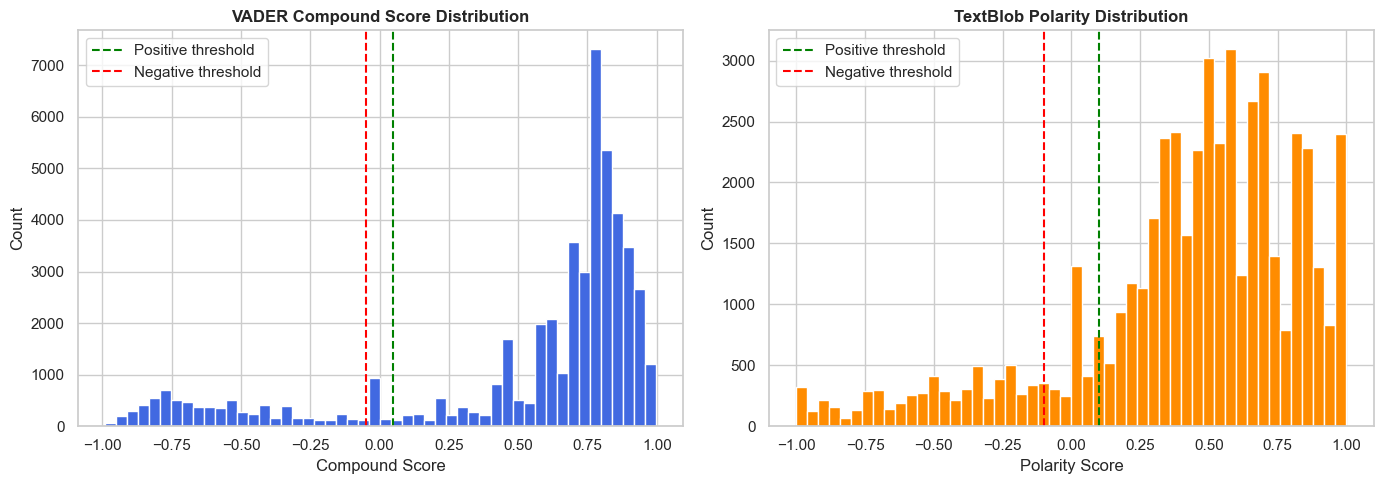

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_sample['vader_compound'], bins=50, color='royalblue', edgecolor='white')
axes[0].axvline(0.05, color='green', linestyle='--', label='Positive threshold')
axes[0].axvline(-0.05, color='red', linestyle='--', label='Negative threshold')
axes[0].set_title('VADER Compound Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(df_sample['textblob_polarity'], bins=50, color='darkorange', edgecolor='white')
axes[1].axvline(0.1, color='green', linestyle='--', label='Positive threshold')
axes[1].axvline(-0.1, color='red', linestyle='--', label='Negative threshold')
axes[1].set_title('TextBlob Polarity Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Polarity Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('polarity_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Word Cloud Analysis

In [37]:
# Stopwords
STOP_WORDS = set(['the','a','an','is','in','it','of','and','to','was','for',
                  'this','that','with','on','are','be','have','from',
                  'had','has','at','i','my','your','they','we','our','very',
                  'but','not','so','just','do','did','as','by','or','if','its',
                  'me','he','she','him','her','us','them','you'])

def get_text_for_class(label):
    txt = ' '.join(df_sample[df_sample['sentiment_label']==label]['clean_review'].dropna())
    return txt

pos_text = get_text_for_class('Positive')
neg_text = get_text_for_class('Negative')
neu_text = get_text_for_class('Neutral')
print("Text lengths:", len(pos_text), len(neg_text), len(neu_text))

Text lengths: 496989 132877 41373


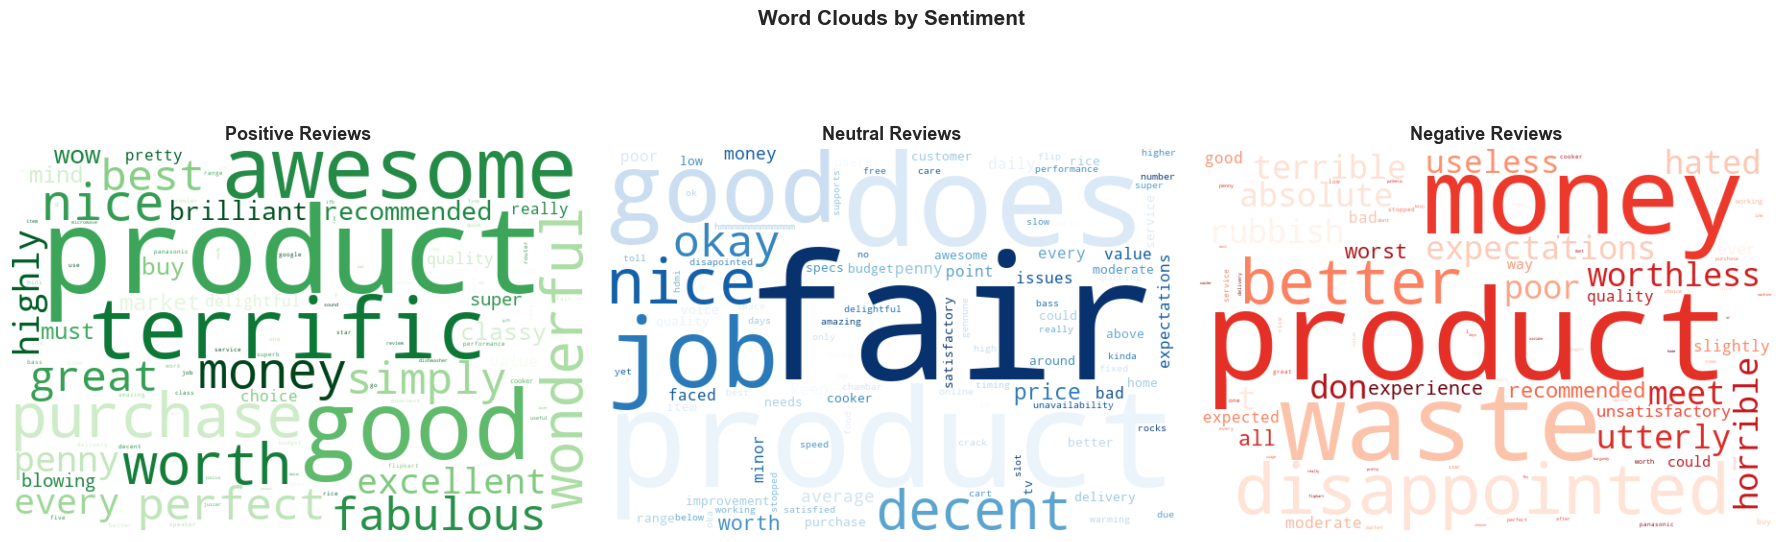

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, text, cmap) in zip(axes, [
    ('Positive Reviews', pos_text, 'Greens'),
    ('Neutral Reviews', neu_text, 'Blues'),
    ('Negative Reviews', neg_text, 'Reds')
]):
    wc = WordCloud(width=600, height=400, background_color='white',
                   stopwords=STOP_WORDS, colormap=cmap,
                   max_words=100, collocations=False).generate(text or 'no data')
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label, fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

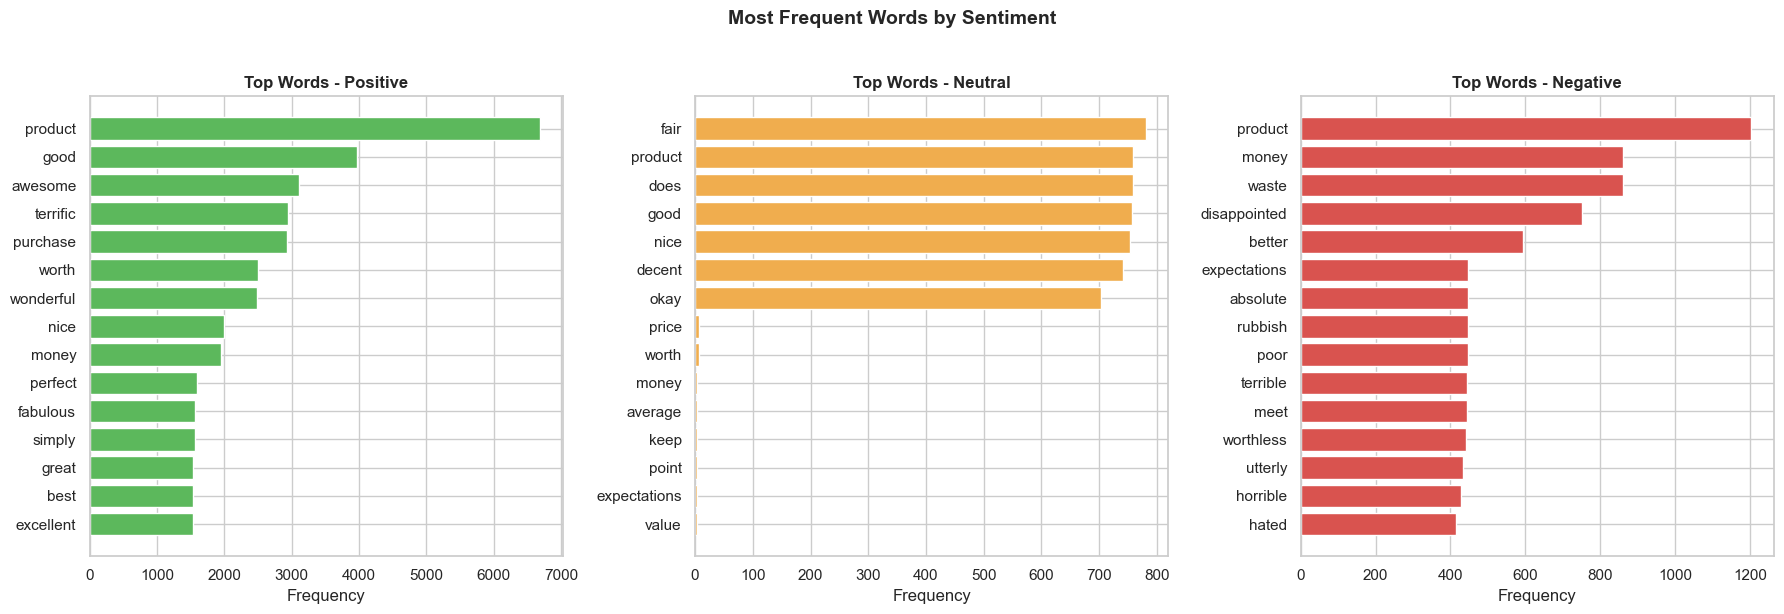

In [39]:
# Top 15 words per sentiment
def top_words(text, n=15):
    words = [w for w in text.split() if len(w) > 3 and w not in STOP_WORDS]
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (label, text, color) in zip(axes, [
    ('Positive', pos_text, '#5cb85c'),
    ('Neutral', neu_text, '#f0ad4e'),
    ('Negative', neg_text, '#d9534f')
]):
    words, counts = zip(*top_words(text))
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top Words - {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words by Sentiment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Machine Learning Model - Sentiment Classifier

In [40]:
# Prepare data for ML
X = df_sample['combined_text']
y = df_sample['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")
print("\nClass distribution in train:")
print(y_train.value_counts())

Train size: 40,000
Test size:  10,000

Class distribution in train:
sentiment_label
Positive    29957
Negative     6394
Neutral      3649
Name: count, dtype: int64


In [41]:
# Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                               sublinear_tf=True, min_df=2)),
    ('clf', LogisticRegression(max_iter=500, C=1.0, random_state=42, n_jobs=-1))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

Logistic Regression Accuracy: 0.9811


In [42]:
# Naive Bayes Pipeline
nb_pipeline = Pipeline([
    ('cvec', CountVectorizer(max_features=20000, ngram_range=(1,2), min_df=2)),
    ('clf', MultinomialNB(alpha=0.5))
])

nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)
nb_acc = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {nb_acc:.4f}")

Naive Bayes Accuracy: 0.9560


In [43]:
# Detailed classification report - Logistic Regression
print("=== Logistic Regression Classification Report ===")
print(classification_report(y_test, y_pred_lr, target_names=['Negative','Neutral','Positive']))

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

    Negative       0.99      0.98      0.98      1598
     Neutral       0.98      0.85      0.91       913
    Positive       0.98      1.00      0.99      7489

    accuracy                           0.98     10000
   macro avg       0.98      0.94      0.96     10000
weighted avg       0.98      0.98      0.98     10000



In [44]:
# Detailed classification report - Naive Bayes
print("=== Naive Bayes Classification Report ===")
print(classification_report(y_test, y_pred_nb, target_names=['Negative','Neutral','Positive']))

=== Naive Bayes Classification Report ===
              precision    recall  f1-score   support

    Negative       0.97      0.96      0.96      1598
     Neutral       0.76      0.82      0.79       913
    Positive       0.98      0.97      0.98      7489

    accuracy                           0.96     10000
   macro avg       0.90      0.92      0.91     10000
weighted avg       0.96      0.96      0.96     10000



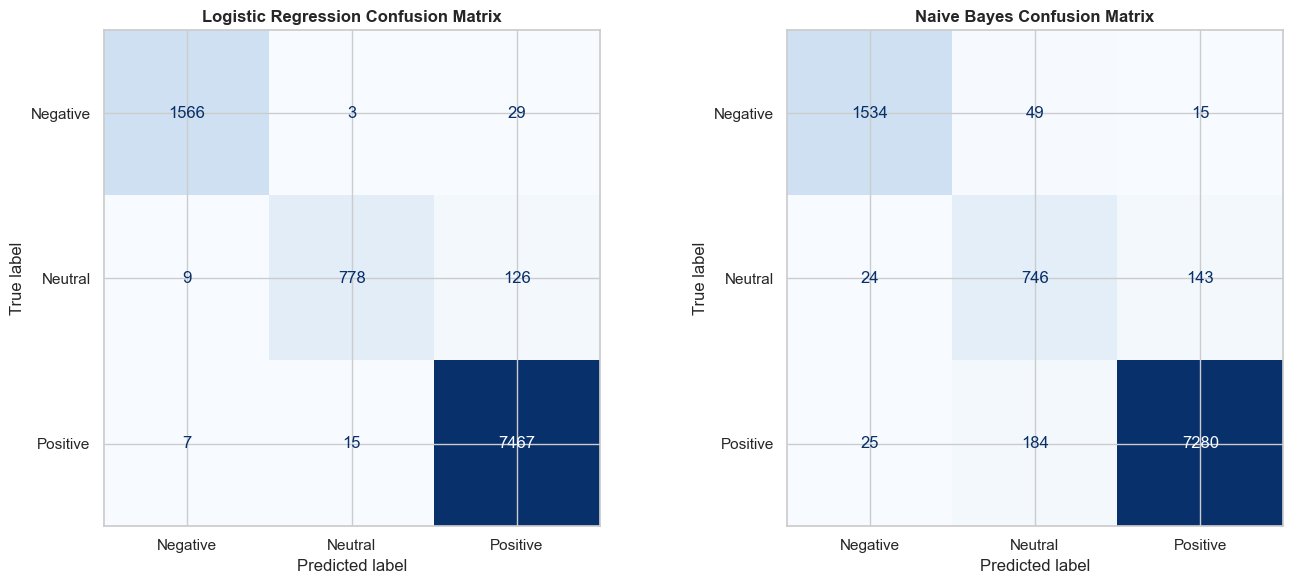

In [45]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_pred, title) in zip(axes, [
    (y_pred_lr, 'Logistic Regression'),
    (y_pred_nb, 'Naive Bayes')
]):
    cm = confusion_matrix(y_test, y_pred, labels=['Negative','Neutral','Positive'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Negative','Neutral','Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# Model performance comparison
from sklearn.metrics import f1_score

models_perf = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'VADER', 'TextBlob'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(df_sample['sentiment_label'], df_sample['vader_sentiment']),
        accuracy_score(df_sample['sentiment_label'], df_sample['textblob_sentiment'])
    ],
    'F1 (Macro)': [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_nb, average='macro'),
        f1_score(df_sample['sentiment_label'], df_sample['vader_sentiment'], average='macro'),
        f1_score(df_sample['sentiment_label'], df_sample['textblob_sentiment'], average='macro')
    ]
})
models_perf = models_perf.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("Model Performance Summary:")
models_perf

Model Performance Summary:


,Model,Accuracy,F1 (Macro)
0,Logistic Regression,0.98110,0.961222
1,Naive Bayes,0.95600,0.909491
2,VADER,0.86682,0.618276
3,TextBlob,0.84954,0.625809


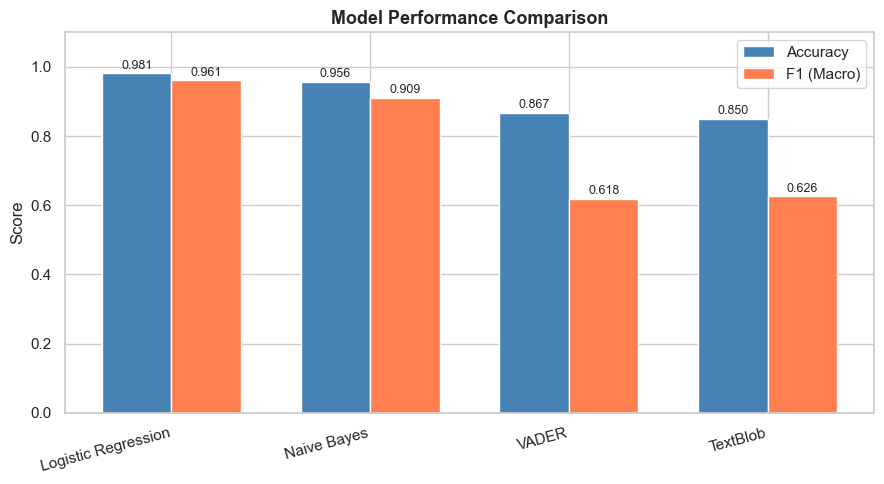

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(models_perf))
width = 0.35
bars1 = ax.bar(x - width/2, models_perf['Accuracy'], width, label='Accuracy',
               color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, models_perf['F1 (Macro)'], width, label='F1 (Macro)',
               color='coral', edgecolor='white')
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(models_perf['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Feature Importance

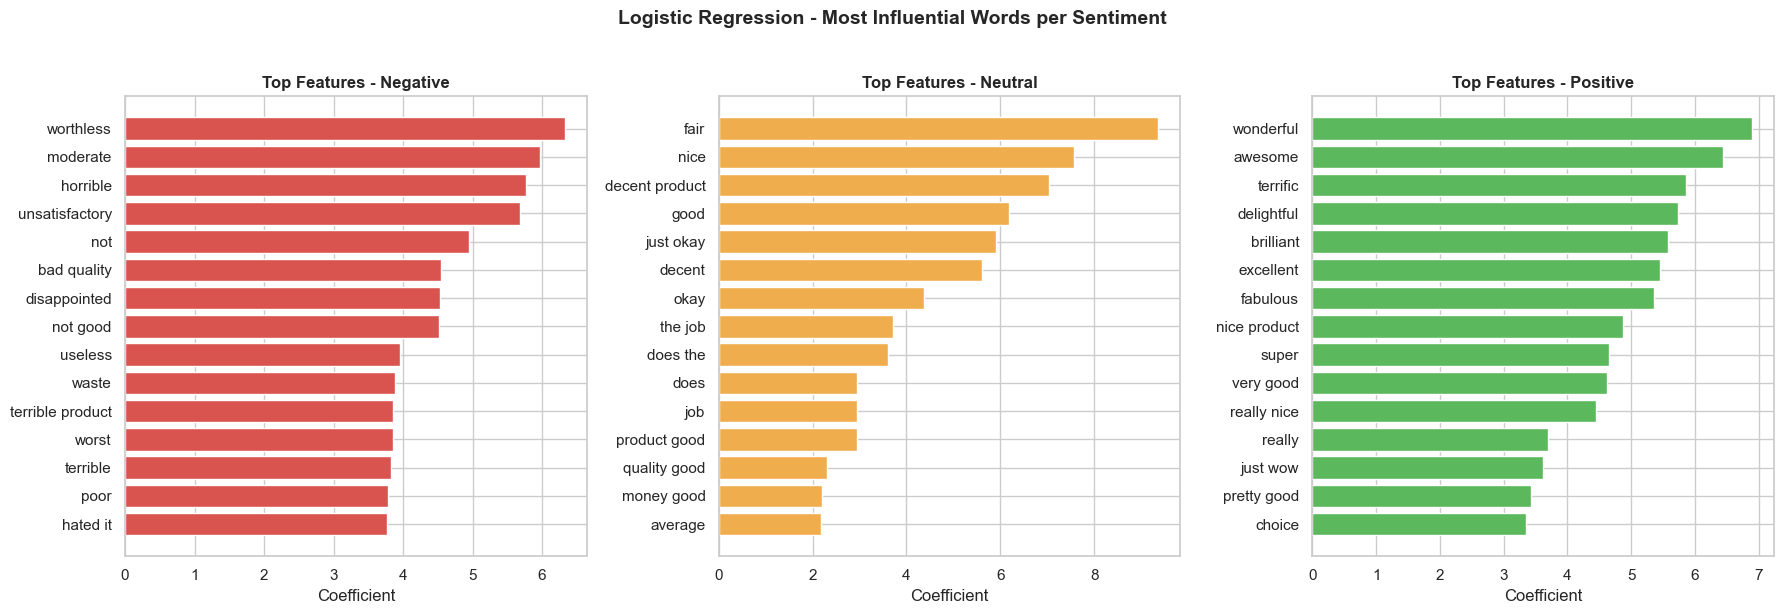

In [48]:
# Top TF-IDF features for each class (Logistic Regression)
tfidf = lr_pipeline.named_steps['tfidf']
clf = lr_pipeline.named_steps['clf']
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
classes = clf.classes_
colors_map = {'Negative':'#d9534f', 'Neutral':'#f0ad4e', 'Positive':'#5cb85c'}

for ax, cls in zip(axes, classes):
    idx = list(classes).index(cls)
    coefs = clf.coef_[idx]
    top_idx = np.argsort(coefs)[-15:]
    top_feats = feature_names[top_idx]
    top_coefs = coefs[top_idx]
    ax.barh(top_feats, top_coefs, color=colors_map.get(cls, 'gray'), edgecolor='white')
    ax.set_title(f'Top Features - {cls}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient')

plt.suptitle('Logistic Regression - Most Influential Words per Sentiment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Predict Sentiment on New Text

In [53]:
def predict_sentiment(text, model=lr_pipeline):
    cleaned = clean_text(text)
    pred = model.predict([cleaned])[0]
    proba = model.predict_proba([cleaned])[0]
    classes = model.classes_
    proba_dict = dict(zip(classes, proba))
    print(f"Text: {text[:80]}")
    print(f"Predicted Sentiment: {pred}")
    print(f"Confidence: {max(proba):.2%}")
    print(f"Probabilities: {proba_dict}")
    return pred

# Test examples
print("===================================================================================" )
predict_sentiment("This product is absolutely amazing! I loved it completely!")
print()
predict_sentiment("The quality is okay but delivery took too long and packaging was bad.")
print()
predict_sentiment("Worst purchase ever. Broke within a week. Do not buy.")

Text: This product is absolutely amazing! I loved it completely!
Predicted Sentiment: Positive
Confidence: 89.15%
Probabilities: {'Negative': np.float64(0.054667388056153225), 'Neutral': np.float64(0.05382283560768983), 'Positive': np.float64(0.891509776336157)}

Text: The quality is okay but delivery took too long and packaging was bad.
Predicted Sentiment: Positive
Confidence: 48.88%
Probabilities: {'Negative': np.float64(0.15547596740265252), 'Neutral': np.float64(0.35568692595895435), 'Positive': np.float64(0.4888371066383932)}

Text: Worst purchase ever. Broke within a week. Do not buy.
Predicted Sentiment: Negative
Confidence: 95.09%
Probabilities: {'Negative': np.float64(0.9509159039271418), 'Neutral': np.float64(0.016741531394066523), 'Positive': np.float64(0.032342564678791666)}


'Negative'

## 16. Save Processed Dataset

In [50]:
# Save the enriched sample dataset
df_sample.to_csv('processed_reviews.csv', index=False)
print(f"Saved processed_reviews.csv with {len(df_sample):,} rows and {df_sample.shape[1]} columns")
print("\nColumns in saved file:")
print(df_sample.columns.tolist())

Saved processed_reviews.csv with 50,000 rows and 15 columns

Columns in saved file:
['Product_name', 'Price', 'Rate', 'Review', 'Summary', 'sentiment_label', 'clean_review', 'clean_summary', 'combined_text', 'review_length', 'summary_length', 'vader_sentiment', 'vader_compound', 'textblob_sentiment', 'textblob_polarity']


## 17. Project Summary

| Component | Details |
|-----------|---------|
| Dataset | Flipkart Product Reviews (~363K rows) |
| Features | Product name, Price, Rating (1-5), Review text, Summary |
| Target | Sentiment: Positive / Neutral / Negative |
| Labeling Methods | Rating-based, VADER, TextBlob |
| ML Models | Logistic Regression (TF-IDF), Naive Bayes (CountVec) |
| Best ML Accuracy | Logistic Regression |
| Key Findings | - ~70%+ reviews are Positive (4-5 stars) |
|  | - Logistic Regression outperforms rule-based methods |
|  | - VADER agrees with rating labels ~75% of the time |

**Key Takeaways:**
- Supervised ML (Logistic Regression) gives the best accuracy when rating labels are available
- VADER is a strong zero-shot baseline for unseen text
- Review length is longer for negative reviews indicating dissatisfied customers write more
- Price range has minimal impact on average rating
